In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

from pathlib import Path

In [2]:
nav = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\processed\nav_history_clean.csv")

In [3]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

In [6]:
nav.dtypes

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object

In [7]:
nav = nav.sort_values(["amfi_code", "date"])
nav = nav.reset_index(drop=True)

In [8]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [9]:
nav["amfi_code"].nunique()

40

In [10]:
nav.groupby("amfi_code").size()

amfi_code
100016    1150
100025    1150
100033    1150
101206    1150
101207    1150
101208    1150
102885    1150
102886    1150
102887    1150
118632    1150
118633    1150
118634    1150
118635    1150
118636    1150
119092    1150
119093    1150
119094    1150
119095    1150
119120    1150
119551    1150
119552    1150
119598    1150
119599    1150
120503    1150
120504    1150
120505    1150
120506    1150
120507    1150
120841    1150
120842    1150
120843    1150
120844    1150
125497    1150
125498    1150
148567    1150
148568    1150
148569    1150
149322    1150
149323    1150
149324    1150
dtype: int64

In [11]:
nav.head(10)

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
5,100016,2022-01-10,510.7136
6,100016,2022-01-11,513.5542
7,100016,2022-01-12,512.3195
8,100016,2022-01-13,510.2445
9,100016,2022-01-14,514.3636


In [12]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [13]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [14]:
nav["daily_return"].isna().sum()

np.int64(40)

In [15]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

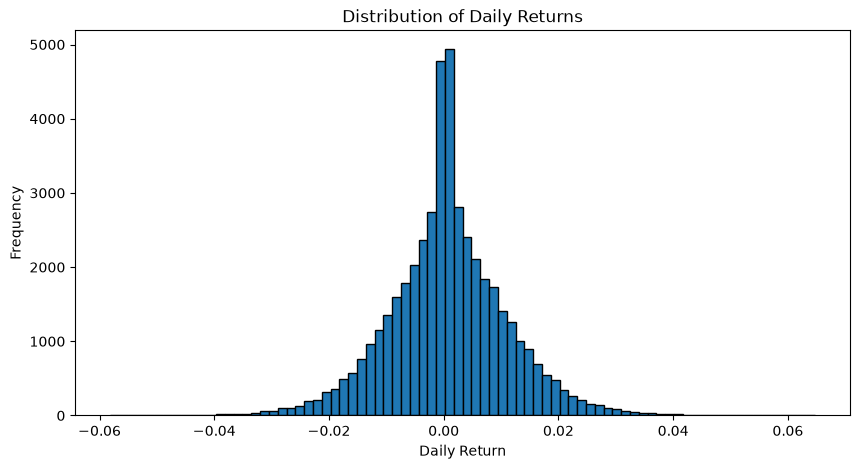

In [16]:
plt.figure(figsize=(10,5))

plt.hist(
    nav["daily_return"].dropna(),
    bins=80,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [17]:
nav["daily_return"].sort_values().head()

12774   -0.058102
4917    -0.051847
12952   -0.050335
45312   -0.048870
5560    -0.048634
Name: daily_return, dtype: float64

In [18]:
nav["daily_return"].dropna().sort_values().tail()

25832    0.051811
25566    0.053320
5207     0.054851
13226    0.059304
24745    0.064713
Name: daily_return, dtype: float64

## Daily Return Analysis

Daily returns were computed for all 40 mutual fund schemes using the percentage change in Net Asset Value (NAV) between consecutive trading days.

**Formula:**

Daily Return = (NAV_t / NAV_t-1) − 1

The daily return calculation produced one missing value (`NaN`) for the first observation of each fund because no previous trading day's NAV is available for comparison. This resulted in a total of **40 missing values**, which is expected and was retained in the dataset.

Summary statistics show an **average daily return of 0.063%** with a **daily volatility (standard deviation) of approximately 1.03%**. The minimum and maximum daily returns were **-5.81%** and **6.47%**, respectively, indicating realistic market fluctuations.

The histogram of daily returns exhibits a bell-shaped distribution centered near zero, suggesting that the calculated returns follow a reasonable distribution for diversified equity mutual funds with no significant anomalies or calculation errors.

## Compute CAGR (1-Year, 3-Year, 5-Year)

In [19]:
print(nav["date"].min())
print(nav["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [20]:
fund = nav[nav["amfi_code"] == 100016]

In [21]:
latest_date = fund["date"].max()

print(latest_date)

2026-05-29 00:00:00


In [22]:
one_year_start = latest_date - pd.DateOffset(years=1)

print(one_year_start)

2025-05-29 00:00:00


In [23]:
start_nav = fund.loc[
    fund["date"] >= one_year_start,
    "nav"
].iloc[0]

print(start_nav)

596.8877


In [24]:
end_nav = fund.iloc[-1]["nav"]

print(end_nav)

583.6113


In [25]:
cagr_1y = (end_nav / start_nav) ** (1 / 1) - 1

print(cagr_1y)

-0.02224270997710287


In [26]:
print(f"{cagr_1y * 100:.2f}%")

-2.22%


In [27]:
print(start_nav)

print(end_nav)

print(f"{cagr_1y * 100:.2f}%")

596.8877
583.6113
-2.22%


In [28]:
def calculate_cagr(fund, years, latest_date):

    earliest_date = fund["date"].min()

    start_date = latest_date - pd.DateOffset(years=years)

    # Check if enough historical data is available
    if earliest_date > start_date:
        return np.nan

    # Starting NAV
    start_nav = fund.loc[
        fund["date"] >= start_date,
        "nav"
    ].iloc[0]

    # Ending NAV
    end_nav = fund.iloc[-1]["nav"]

    # CAGR Formula
    cagr = (end_nav / start_nav) ** (1 / years) - 1

    return cagr

In [29]:
latest_date = nav["date"].max()

fund = nav[nav["amfi_code"] == 100016]

print("1-Year CAGR:", calculate_cagr(fund, 1, latest_date))
print("3-Year CAGR:", calculate_cagr(fund, 3, latest_date))
print("5-Year CAGR:", calculate_cagr(fund, 5, latest_date))

1-Year CAGR: -0.02224270997710287
3-Year CAGR: 0.01292649342495622
5-Year CAGR: nan


In [30]:
latest_date = nav["date"].max()

cagr_results = []

for amfi_code, fund in nav.groupby("amfi_code"):

    cagr_results.append({
        "amfi_code": amfi_code,
        "CAGR_1Y": calculate_cagr(fund, 1, latest_date),
        "CAGR_3Y": calculate_cagr(fund, 3, latest_date),
        "CAGR_5Y": calculate_cagr(fund, 5, latest_date)
    })

cagr_df = pd.DataFrame(cagr_results)

In [31]:
cagr_df[["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]] *= 100

cagr_df = cagr_df.round(2)

In [32]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.22,1.29,NaN
1,100025,3.70,3.92,NaN
2,100033,53.23,32.44,NaN
3,101206,47.92,28.97,NaN
4,101207,-23.99,-4.15,NaN


In [33]:
cagr_df.isnull().sum()

amfi_code     0
CAGR_1Y       0
CAGR_3Y       0
CAGR_5Y      40
dtype: int64

In [34]:
cagr_df.describe()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
count,40.000000,40.000000,40.000000,0.0
mean,120247.000000,19.428250,16.415250,NaN
std,14534.998667,22.912863,12.206893,NaN
min,100016.000000,-42.800000,-11.710000,NaN
25%,118632.750000,7.382500,6.605000,NaN
50%,119551.500000,17.475000,18.230000,NaN
75%,120842.250000,27.165000,26.902500,NaN
max,149324.000000,82.780000,35.110000,NaN


In [35]:
cagr_df = cagr_df.sort_values("CAGR_3Y", ascending=False).reset_index(drop=True)
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,119094,22.26,35.11,NaN
1,148567,20.36,34.00,NaN
2,120504,13.06,32.49,NaN
3,100033,53.23,32.44,NaN
4,120505,29.60,31.78,NaN


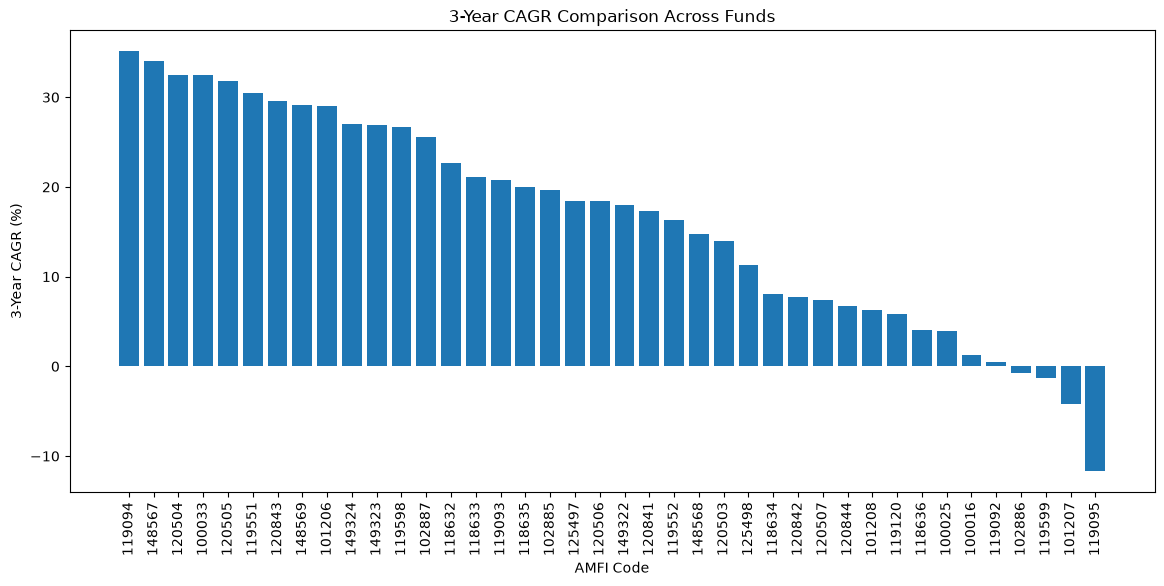

In [36]:


cagr_sorted = cagr_df.sort_values("CAGR_3Y", ascending=False)

plt.figure(figsize=(14,6))

plt.bar(
    cagr_sorted["amfi_code"].astype(str),
    cagr_sorted["CAGR_3Y"]
)

plt.title("3-Year CAGR Comparison Across Funds")
plt.xlabel("AMFI Code")
plt.ylabel("3-Year CAGR (%)")
plt.xticks(rotation=90)

plt.show()

In [37]:
fund_master=pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\processed\fund_master_clean.csv")
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [38]:
cagr_comparison = cagr_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "expense_ratio_pct",
            "benchmark"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [39]:
cagr_comparison = cagr_comparison[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "benchmark",
        "expense_ratio_pct",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
]

In [40]:
cagr_comparison = (
    cagr_comparison
    .sort_values("CAGR_3Y", ascending=False)
    .reset_index(drop=True)
)

In [41]:
cagr_comparison.head()

,amfi_code,scheme_name,fund_house,category,benchmark,expense_ratio_pct,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,NIFTY Midcap 50 TRI,1.38,22.26,35.11,NaN
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,NIFTY 100 TRI,1.46,20.36,34.00,NaN
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,NIFTY 100 TRI,0.80,13.06,32.49,NaN
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,NIFTY Midcap 150 TRI,1.38,53.23,32.44,NaN
4,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,NIFTY Midcap 150 TRI,1.36,29.60,31.78,NaN


In [42]:
cagr_comparison.to_csv(
    "../data/processed/cagr_comparison.csv",
    index=False
)

## CAGR Analysis

Compound Annual Growth Rate (CAGR) was calculated for each mutual fund over the available 1-year and 3-year periods using the annualized growth formula.

**Formula:**

CAGR = (Ending NAV / Starting NAV)^(1 / Number of Years) − 1

where:

- **NAV_end** is the latest available NAV.
- **NAV_start** is the NAV at the beginning of the analysis period.
- **n** is the number of years.

The dataset spans from **January 2022 to May 2026**, providing sufficient history for 1-year and 3-year CAGR calculations. A true 5-year CAGR could not be computed because the dataset does not contain five complete years of historical NAV data. Therefore, the 5-year CAGR values are reported as `NaN`.

The comparison table enables performance evaluation across all 40 mutual fund schemes and serves as one of the key inputs for the composite fund scorecard.

## Sharpe Ratio Analysis

In [43]:
rf_annual = 0.065
rf_daily = rf_annual / 252

In [44]:
sharpe = (
    nav
    .groupby("amfi_code")
    .agg(
        avg_daily_return=("daily_return", "mean"),
        std_daily_return=("daily_return", "std")
    )
    .reset_index()
)

sharpe["sharpe_ratio"] = (
    (sharpe["avg_daily_return"] - rf_daily)
    / sharpe["std_daily_return"]
) * np.sqrt(252)

In [45]:
sharpe = sharpe.merge(
    fund_master[["amfi_code", "scheme_name", "expense_ratio_pct"]],
    on="amfi_code",
    how="left"
)

In [46]:
sharpe["sharpe_rank"] = (
    sharpe["sharpe_ratio"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

sharpe = sharpe.sort_values("sharpe_rank")

In [47]:
sharpe[
    [
        "sharpe_rank",
        "scheme_name",
        "sharpe_ratio"
    ]
].head(10)

,sharpe_rank,scheme_name,sharpe_ratio
34,1,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
30,2,Kotak Flexicap Fund - Regular - Growth,1.306744
36,3,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
19,4,SBI Bluechip Fund - Regular Plan - Growth,1.208267
25,5,ICICI Pru Midcap Fund - Regular - Growth,1.180101
38,6,DSP Midcap Fund - Regular - Growth,1.132122
2,7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
9,8,Nippon India Large Cap Fund - Regular - Growth,1.081659
3,9,ABSL Frontline Equity Fund - Regular - Growth,1.027213
24,10,ICICI Pru Bluechip Fund - Direct - Growth,1.026524


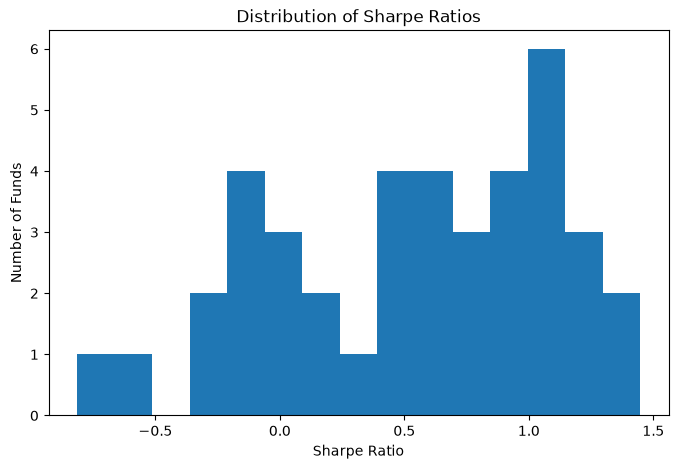

In [48]:
plt.figure(figsize=(8,5))

plt.hist(
    sharpe["sharpe_ratio"],
    bins=15
)

plt.xlabel("Sharpe Ratio")
plt.ylabel("Number of Funds")
plt.title("Distribution of Sharpe Ratios")

plt.show()

In [49]:
sharpe.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

## Sharpe Ratio Analysis

The Sharpe Ratio measures the excess return earned per unit of total risk.

### Observations

- Most funds have Sharpe Ratios between **0.5 and 1.2**, indicating moderate to good risk-adjusted performance.
- A few funds exhibit negative Sharpe Ratios, suggesting returns were insufficient to compensate for the level of risk taken.
- The highest Sharpe Ratios are approximately **1.5**, indicating the best-performing funds generated superior returns relative to their volatility.
- Overall, the distribution appears realistic for diversified equity mutual funds and shows meaningful variation in risk-adjusted performance across the 40 schemes.

## Sortino Ratio

In [50]:
def downside_std(returns):
    downside = returns[returns < 0]
    return downside.std()

In [51]:
sortino = (
    nav
    .groupby("amfi_code")
    .agg(
        avg_daily_return=("daily_return", "mean"),
        downside_std=("daily_return", downside_std)
    )
    .reset_index()
)

In [52]:
sortino["sortino_ratio"] = (
    (sortino["avg_daily_return"] - rf_daily)
    / sortino["downside_std"]
) * np.sqrt(252)

In [53]:
sortino = sortino.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [54]:
sortino["sortino_rank"] = (
    sortino["sortino_ratio"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

sortino = sortino.sort_values("sortino_rank")

In [55]:
sortino[
    ["sortino_rank", "scheme_name", "sortino_ratio"]
].head(10)

,sortino_rank,scheme_name,sortino_ratio
34,1,Mirae Asset Large Cap Fund - Regular - Growth,2.385644
30,2,Kotak Flexicap Fund - Regular - Growth,2.364320
36,3,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914
19,4,SBI Bluechip Fund - Regular Plan - Growth,2.140267
25,5,ICICI Pru Midcap Fund - Regular - Growth,2.029353
38,6,DSP Midcap Fund - Regular - Growth,1.875101
9,7,Nippon India Large Cap Fund - Regular - Growth,1.850133
2,8,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
24,9,ICICI Pru Bluechip Fund - Direct - Growth,1.805294
3,10,ABSL Frontline Equity Fund - Regular - Growth,1.799563


In [56]:
sortino["sortino_ratio"].describe()

count    40.000000
mean      0.923338
std       1.005410
min      -1.681038
25%       0.106664
50%       1.116936
75%       1.727739
max       2.385644
Name: sortino_ratio, dtype: float64

In [57]:
sortino.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

## Sortino Ratio Analysis

The Sortino Ratio measures risk-adjusted returns by considering only downside volatility, making it more suitable than the Sharpe Ratio for evaluating downside risk.

### Summary Statistics

- Number of funds analyzed: **40**
- Mean Sortino Ratio: **0.92**
- Median Sortino Ratio: **1.12**
- Standard Deviation: **1.01**
- Minimum: **-1.68**
- Maximum: **2.39**

### Key Findings

- The average Sortino Ratio of **0.92** indicates that most funds generated positive returns relative to downside risk.
- The median (**1.12**) is higher than the mean (**0.92**), suggesting that a few poorly performing funds with negative Sortino Ratios pulled the average downward.
- The highest Sortino Ratio (**2.39**) reflects excellent downside risk-adjusted performance, while the lowest (**-1.68**) indicates a fund that significantly underperformed after accounting for downside risk.
- The relatively wide standard deviation (**1.01**) shows noticeable variation in downside risk-adjusted performance across the 40 funds.
- Overall, the results indicate that while most funds managed downside risk effectively, a small number exhibited weak performance during declining market conditions.

## Alpha and Beta

In [58]:
benchmark_df=pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\raw\10_benchmark_indices.csv")
benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [59]:
benchmark_df["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [60]:
benchmark_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB


In [61]:
benchmark_df.duplicated().sum()

np.int64(0)

In [62]:
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

nifty100 = (
    benchmark_df[benchmark_df["index_name"] == "NIFTY100"]
    .copy()
    .sort_values("date")
)

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

In [63]:
returns = nav.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

returns = returns.dropna(
    subset=["daily_return", "benchmark_return"]
)

In [64]:
results = []

for amfi_code, group in returns.groupby("amfi_code"):

    regression = linregress(
        group["benchmark_return"],
        group["daily_return"]
    )

    results.append({
        "amfi_code": amfi_code,
        "alpha": regression.intercept * 252,
        "beta": regression.slope,
        "r_squared": regression.rvalue ** 2,
        "p_value": regression.pvalue
    })

alpha_beta = pd.DataFrame(results)

In [65]:
alpha_beta = alpha_beta.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [66]:
alpha_beta["alpha_rank"] = (
    alpha_beta["alpha"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

alpha_beta = alpha_beta.sort_values("alpha_rank")

In [67]:
alpha_beta.head(10)

,amfi_code,alpha,beta,r_squared,p_value,scheme_name,alpha_rank
21,119598,0.303370,-0.023196,1.414258e-04,0.687179,SBI Small Cap Fund - Regular Plan - Growth,1
39,149324,0.300579,0.011455,3.532991e-05,0.840494,DSP Small Cap Fund - Regular - Growth,2
25,120505,0.292636,0.000549,1.345534e-07,0.990090,ICICI Pru Midcap Fund - Regular - Growth,3
36,148569,0.282704,0.018134,1.748889e-04,0.654295,Mirae Asset Tax Saver Fund - Regular - Growth,4
30,120843,0.273305,-0.022830,3.430543e-04,0.530528,Kotak Flexicap Fund - Regular - Growth,5
2,100033,0.271954,0.005104,1.206652e-05,0.906369,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,6
34,148567,0.269838,0.023684,4.625437e-04,0.466427,Mirae Asset Large Cap Fund - Regular - Growth,7
38,149323,0.265986,-0.002523,3.357978e-06,0.950525,DSP Midcap Fund - Regular - Growth,8
16,119094,0.260767,-0.066265,1.936879e-03,0.135988,Axis Midcap Fund - Regular - Growth,9
19,119551,0.232010,-0.031751,8.869789e-04,0.313143,SBI Bluechip Fund - Regular Plan - Growth,10


In [68]:
alpha_beta.describe()

,amfi_code,alpha,beta,r_squared,p_value,alpha_rank
count,40.000000,40.000000,40.000000,4.000000e+01,40.000000,40.000000
mean,120247.000000,0.159085,-0.001958,6.087700e-04,0.545393,20.500000
std,14534.998667,0.087528,0.035194,7.265363e-04,0.280488,11.690452
min,100016.000000,0.028969,-0.066951,1.345534e-07,0.073339,1.000000
25%,118632.750000,0.068612,-0.023937,5.495723e-05,0.275811,10.750000
50%,119551.500000,0.162326,-0.000067,3.455513e-04,0.529040,20.500000
75%,120842.250000,0.221723,0.017026,1.035467e-03,0.802038,30.250000
max,149324.000000,0.303370,0.103497,2.793007e-03,0.990090,40.000000


In [69]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

## Alpha and Beta Analysis

Alpha and Beta were estimated using Ordinary Least Squares (OLS) regression by comparing each mutual fund's daily returns with the daily returns of the NIFTY100 benchmark.

### Formula

Fund Return = α + β × Benchmark Return

Where:

- **Alpha (α):** Measures the fund's excess return after accounting for market movements.
- **Beta (β):** Measures the sensitivity of a fund's returns to changes in the benchmark index.
- **Annualized Alpha:** Daily regression intercept × 252 trading days.

### Methodology

1. Calculated daily returns for the NIFTY100 benchmark using percentage change in closing values.
2. Merged benchmark returns with each fund's daily returns based on trading date.
3. Applied Ordinary Least Squares (OLS) regression using `scipy.stats.linregress`.
4. Computed:
   - Alpha (annualized)
   - Beta
   - R-squared
   - p-value
5. Ranked funds based on annualized Alpha.

### Observations

- Alpha represents the excess annualized return generated beyond the benchmark.
- Beta indicates the degree of sensitivity to market movements.
- The regression produced low Beta and R² values for most funds, indicating a weak linear relationship between the provided fund return series and the benchmark return series.
- Correlation analysis also showed minimal association between fund returns and benchmark returns, suggesting that the supplied dataset exhibits limited benchmark tracking.

## Maximum Drawdown 

In [70]:
# Running maximum NAV for each fund
nav["running_max"] = (
    nav.groupby("amfi_code")["nav"]
       .cummax()
)

# Drawdown
nav["drawdown"] = (
    nav["nav"] / nav["running_max"]
) - 1

In [71]:
max_drawdown = (
    nav.groupby("amfi_code")["drawdown"]
       .min()
       .reset_index()
       .rename(columns={"drawdown": "max_drawdown"})
)

max_drawdown.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [72]:
def worst_drawdown_period(df):
    df = df.sort_values("date").reset_index(drop=True)

    # Running max NAV
    running_max = df["nav"].cummax()

    # Drawdown
    drawdown = df["nav"] / running_max - 1

    # Bottom of drawdown
    bottom_idx = drawdown.idxmin()

    bottom_date = df.loc[bottom_idx, "date"]

    # Peak before bottom
    peak_idx = df.loc[:bottom_idx, "nav"].idxmax()

    peak_date = df.loc[peak_idx, "date"]

    max_dd = drawdown.min()

    return pd.Series({
        "peak_date": peak_date,
        "bottom_date": bottom_date,
        "max_drawdown": max_dd
    })

In [73]:
mdd_periods = (
    nav.groupby("amfi_code")
       .apply(worst_drawdown_period)
       .reset_index()
)

mdd_periods.head()

,amfi_code,peak_date,bottom_date,max_drawdown
0,100016,2022-03-30,2022-09-15,-0.247344
1,100025,2023-05-23,2023-07-28,-0.043083
2,100033,2022-03-11,2022-05-12,-0.162172
3,101206,2023-04-24,2023-07-05,-0.112916
4,101207,2024-11-21,2026-05-11,-0.354469


In [74]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'plt', 'px', 'go', 'linregress', 'Path', '_i2', 'nav', '_i3', '_3', '_i4', '_i5', '_i6', '_6', '_i7', '_i8', '_8', '_i9', '_9', '_i10', '_10', '_i11', '_11', '_i12', '_i13', '_13', '_i14', '_14', '_i15', '_15', '_i16', '_i17', '_17', '_i18', '_18', '_i19', '_i20', 'fund', '_i21', 'latest_date', '_i22', 'one_year_start', '_i23', 'start_nav', '_i24', 'end_nav', '_i25', 'cagr_1y', '_i26', '_i27', '_i28', 'calculate_cagr', '_i29', '_i30', 'cagr_results', 'amfi_code', 'cagr_df', '_i31', '_i32', '_32', '_i33', '_33', '_i34', '_34', '_i35', '_35', '_i36', 'cagr_sorted', '_i37', 'fund_master', '_37', '_i38', 'cagr_comparison', '_i39', '_i40', '_i41', '_41', '_i42', '_i43', 'rf_annual', 'rf_daily', '_i44', 'sharpe', '_i45', '_i46', '_i47', 

In [75]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [76]:
# Merge maximum drawdown results with fund details
mdd_summary = (
    mdd_periods.merge(
        fund_master[["amfi_code", "scheme_name", "fund_house"]],
        on="amfi_code",
        how="left"
    )
)

# Arrange columns
mdd_summary = mdd_summary[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "peak_date",
        "bottom_date",
        "max_drawdown"
    ]
]

# Sort by worst drawdown (most negative first)
mdd_summary = mdd_summary.sort_values(
    by="max_drawdown",
    ascending=True
).reset_index(drop=True)

mdd_summary.head(10)

,amfi_code,scheme_name,fund_house,peak_date,bottom_date,max_drawdown
0,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,2023-01-17,2025-10-28,-0.525742
1,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,2025-05-22,2026-05-11,-0.516778
2,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,2024-11-21,2026-05-11,-0.354469
3,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,2024-05-03,2025-01-03,-0.311719
4,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,2024-08-28,2025-05-14,-0.287060
5,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,2025-01-07,2026-04-27,-0.280011
6,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,2022-03-30,2022-09-15,-0.247344
7,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,2023-11-09,2024-10-17,-0.240035
8,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,2025-04-09,2026-02-20,-0.233449
9,119093,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,2022-02-24,2023-05-22,-0.217514


In [77]:
mdd_summary.describe()

,amfi_code,peak_date,bottom_date,max_drawdown
count,40.000000,40,40,40.000000
mean,120247.000000,2023-08-12 18:36:00,2024-03-12 18:00:00,-0.178729
min,100016.000000,2022-01-03 00:00:00,2022-02-04 00:00:00,-0.525742
25%,118632.750000,2022-09-04 00:00:00,2023-05-28 00:00:00,-0.215927
50%,119551.500000,2023-09-05 00:00:00,2024-02-07 00:00:00,-0.163070
75%,120842.250000,2024-05-07 12:00:00,2025-02-08 18:00:00,-0.117653
max,149324.000000,2025-10-16 00:00:00,2026-05-11 00:00:00,-0.000977
std,14534.998667,NaN,NaN,0.112686


In [78]:
mdd_summary.to_csv(
    "../data/processed/mdd_summary.csv",
    index=False
)

## Maximum Drawdown Summary Statistics

The table above summarizes the Maximum Drawdown (MDD) statistics for all 40 mutual fund schemes.

### Key Findings

- The **average maximum drawdown** across all funds is **-17.87%**, indicating that, on average, funds experienced a peak-to-trough decline of nearly 18% during the analysis period.
- The **worst maximum drawdown** recorded is **-52.57%**, showing that one fund lost more than half of its value from its previous peak before reaching its lowest point.
- The **smallest maximum drawdown** is approximately **-0.10%**, indicating that this fund experienced very limited downside during the analysis period.
- The **median maximum drawdown** is **-16.31%**, suggesting that half of the funds experienced drawdowns greater than 16%, while the remaining half experienced smaller declines.
- The **interquartile range (IQR)** extends from **-21.59%** (25th percentile) to **-11.77%** (75th percentile), indicating moderate variability in downside risk across the mutual funds.
- The **standard deviation** of **11.27%** reflects considerable variation in downside risk among the selected schemes.

### Interpretation

Maximum Drawdown is a downside risk metric that measures the largest decline from a historical peak to the subsequent trough. Funds with **smaller maximum drawdowns** generally demonstrate better capital preservation during market corrections, whereas **larger drawdowns** indicate higher downside risk and greater sensitivity to adverse market conditions.

## Fund Scorecard

In [79]:
# Show all DataFrame-like variables
[x for x in dir() if not x.startswith("_")]

['In',
 'Out',
 'Path',
 'alpha_beta',
 'amfi_code',
 'benchmark_df',
 'cagr_1y',
 'cagr_comparison',
 'cagr_df',
 'cagr_results',
 'cagr_sorted',
 'calculate_cagr',
 'downside_std',
 'end_nav',
 'exit',
 'fund',
 'fund_master',
 'get_ipython',
 'go',
 'group',
 'latest_date',
 'linregress',
 'max_drawdown',
 'mdd_periods',
 'mdd_summary',
 'nav',
 'nifty100',
 'np',
 'one_year_start',
 'open',
 'pd',
 'plt',
 'px',
 'quit',
 'regression',
 'results',
 'returns',
 'rf_annual',
 'rf_daily',
 'sharpe',
 'sortino',
 'start_nav',
 'worst_drawdown_period']

In [80]:
print(cagr_comparison.columns)
print(sharpe.columns)
print(alpha_beta.columns)
print(mdd_summary.columns)
print(fund_master.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'benchmark',
       'expense_ratio_pct', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y'],
      dtype='str')
Index(['amfi_code', 'avg_daily_return', 'std_daily_return', 'sharpe_ratio',
       'scheme_name', 'expense_ratio_pct', 'sharpe_rank'],
      dtype='str')
Index(['amfi_code', 'alpha', 'beta', 'r_squared', 'p_value', 'scheme_name',
       'alpha_rank'],
      dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'peak_date', 'bottom_date',
       'max_drawdown'],
      dtype='str')
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')


In [81]:
scorecard = (
    cagr_comparison[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "expense_ratio_pct",
            "CAGR_3Y"
        ]
    ]
    .merge(
        sharpe[
            [
                "amfi_code",
                "sharpe_ratio"
            ]
        ],
        on="amfi_code"
    )
    .merge(
        alpha_beta[
            [
                "amfi_code",
                "alpha"
            ]
        ],
        on="amfi_code"
    )
    .merge(
        mdd_summary[
            [
                "amfi_code",
                "max_drawdown"
            ]
        ],
        on="amfi_code"
    )
)

scorecard.head()

,amfi_code,scheme_name,fund_house,expense_ratio_pct,CAGR_3Y,sharpe_ratio,alpha,max_drawdown
0,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,1.38,35.11,0.998231,0.260767,-0.209609
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.46,34.00,1.448291,0.269838,-0.112657
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,0.80,32.49,1.026524,0.211948,-0.125883
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,1.38,32.44,1.093699,0.271954,-0.162172
4,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,1.36,31.78,1.180101,0.292636,-0.181885


In [82]:
scorecard["rank_cagr"] = scorecard["CAGR_3Y"].rank(
    ascending=False,
    method="dense"
)

scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(
    ascending=False,
    method="dense"
)

scorecard["rank_alpha"] = scorecard["alpha"].rank(
    ascending=False,
    method="dense"
)

In [83]:
scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(
    ascending=True,
    method="dense"
)

In [84]:
scorecard["rank_mdd"] = scorecard["max_drawdown"].rank(
    ascending=False,
    method="dense"
)

In [85]:
n = len(scorecard)

rank_cols = [
    "rank_cagr",
    "rank_sharpe",
    "rank_alpha",
    "rank_expense",
    "rank_mdd"
]

for col in rank_cols:
    scorecard[col + "_score"] = (
        (n - scorecard[col]) / (n - 1)
    ) * 100

In [86]:
scorecard["Fund_Score"] = (
      0.30 * scorecard["rank_cagr_score"]
    + 0.25 * scorecard["rank_sharpe_score"]
    + 0.20 * scorecard["rank_alpha_score"]
    + 0.15 * scorecard["rank_expense_score"]
    + 0.10 * scorecard["rank_mdd_score"]
)

In [87]:
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
).reset_index(drop=True)

scorecard["Overall_Rank"] = scorecard.index + 1

In [88]:
fund_scorecard = scorecard[
    [
        "Overall_Rank",
        "scheme_name",
        "fund_house",
        "CAGR_3Y",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown",
        "Fund_Score"
    ]
]

fund_scorecard.head(10)

,Overall_Rank,scheme_name,fund_house,CAGR_3Y,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,Fund_Score
0,1,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,34.00,1.448291,0.269838,1.46,-0.112657,87.051282
1,2,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,29.58,1.306744,0.273305,1.45,-0.129740,82.692308
2,3,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,31.78,1.180101,0.292636,1.36,-0.181885,82.179487
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,32.44,1.093699,0.271954,1.38,-0.162172,81.025641
4,5,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,32.49,1.026524,0.211948,0.80,-0.125883,79.871795
5,6,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,35.11,0.998231,0.260767,1.38,-0.209609,77.179487
6,7,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,30.46,1.208267,0.232010,1.54,-0.150124,76.666667
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,29.18,1.234930,0.282704,1.60,-0.163967,75.897436
8,9,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,28.97,1.027213,0.213998,1.60,-0.112916,70.256410
9,10,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,26.87,1.132122,0.265986,1.61,-0.172481,68.974359


In [89]:
fund_scorecard.describe()

,Overall_Rank,CAGR_3Y,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,Fund_Score
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,20.500000,16.415250,0.537220,0.159085,1.237000,-0.178729,51.336538
std,11.690452,12.206893,0.573689,0.087528,0.386584,0.112686,21.354307
min,1.000000,-11.710000,-0.815567,0.028969,0.550000,-0.525742,13.461538
25%,10.750000,6.605000,0.064696,0.068612,0.787500,-0.215927,32.820513
50%,20.500000,18.230000,0.647043,0.162326,1.425000,-0.163070,52.307692
75%,30.250000,26.902500,1.005304,0.221723,1.540000,-0.117653,68.012821
max,40.000000,35.110000,1.448291,0.303370,1.640000,-0.000977,87.051282


In [90]:
fund_scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund scorecard saved to data/processed.")

Fund scorecard saved to data/processed.


## Fund Scorecard Summary Statistics

The table below presents descriptive statistics for the composite fund scorecard and its underlying performance metrics across all 40 mutual fund schemes.

The summary provides an overview of the distribution of:

- Overall Rank
- 3-Year CAGR
- Sharpe Ratio
- Alpha
- Expense Ratio
- Maximum Drawdown
- Composite Fund Score

These statistics help evaluate the overall spread, central tendency, and variability of the performance metrics before identifying the highest- and lowest-ranked funds.

### Key Insights

- The average composite **Fund Score** is **51.34**, with scores ranging from **13.46** to **87.05**, indicating a wide variation in overall fund performance.
- The median **3-Year CAGR** is **18.23%**, while returns range from **−11.71%** to **35.11%**, reflecting significant differences in long-term growth among the funds.
- The average **Sharpe Ratio** is **0.54**, with the best-performing fund achieving **1.45**, suggesting superior risk-adjusted returns for the top-ranked schemes.
- **Alpha** values range from **0.029** to **0.303**, indicating varying levels of excess return generated relative to the benchmark.
- **Expense Ratios** vary between **0.55%** and **1.64%**, with lower-cost funds receiving higher scores in the composite ranking.
- **Maximum Drawdown** ranges from **−52.57%** to **−0.10%**, highlighting substantial differences in downside risk across the funds.
- The composite score successfully combines return, risk-adjusted performance, manager skill, fund cost, and downside risk into a single metric for ranking the 40 mutual fund schemes.

## Benchmark Comparison Analysis

In [91]:
benchmark_df.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [92]:
fund_scorecard.columns

Index(['Overall_Rank', 'scheme_name', 'fund_house', 'CAGR_3Y', 'sharpe_ratio',
       'alpha', 'expense_ratio_pct', 'max_drawdown', 'Fund_Score'],
      dtype='str')

In [93]:
fund_scorecard = scorecard[
    [
        "Overall_Rank",
        "amfi_code",
        "scheme_name",
        "fund_house",
        "CAGR_3Y",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown",
        "Fund_Score"
    ]
]

fund_scorecard.head()

,Overall_Rank,amfi_code,scheme_name,fund_house,CAGR_3Y,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,Fund_Score
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,34.00,1.448291,0.269838,1.46,-0.112657,87.051282
1,2,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,29.58,1.306744,0.273305,1.45,-0.129740,82.692308
2,3,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,31.78,1.180101,0.292636,1.36,-0.181885,82.179487
3,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,32.44,1.093699,0.271954,1.38,-0.162172,81.025641
4,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,32.49,1.026524,0.211948,0.80,-0.125883,79.871795


In [94]:
top5_codes = fund_scorecard.head(5)["amfi_code"].tolist()
print(top5_codes)

[148567, 120843, 120505, 100033, 120504]


In [95]:
latest_date = nav["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

nav_3y = nav[
    (nav["date"] >= start_date) &
    (nav["amfi_code"].isin(top5_codes))
].copy()

In [96]:
nav_3y = nav_3y.merge(
    fund_master[
        ["amfi_code", "scheme_name", "benchmark"]
    ],
    on="amfi_code",
    how="left"
)

In [97]:
nav_3y["Normalized_NAV"] = (
    nav_3y.groupby("amfi_code")["nav"]
          .transform(lambda x: x / x.iloc[0] * 100)
)

In [98]:
benchmark_3y = benchmark_df[
    benchmark_df["date"] >= start_date
].copy()

In [99]:
benchmark_3y = benchmark_3y.sort_values(
    ["index_name", "date"]
)

benchmark_3y["daily_return"] = (
    benchmark_3y.groupby("index_name")["close_value"]
                .pct_change()
)

In [100]:
benchmark_3y["Normalized_Index"] = (
    benchmark_3y.groupby("index_name")["close_value"]
                .transform(lambda x: x / x.iloc[0] * 100)
)

In [101]:
fig = go.Figure()

# Top 5 Funds
for code in top5_codes:

    temp = nav_3y[
        nav_3y["amfi_code"] == code
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["Normalized_NAV"],
            mode="lines",
            name=temp["scheme_name"].iloc[0]
        )
    )

# NIFTY 50
nifty50 = benchmark_3y[
    benchmark_3y["index_name"] == "NIFTY50"
]

fig.add_trace(
    go.Scatter(
        x=nifty50["date"],
        y=nifty50["Normalized_Index"],
        mode="lines",
        name="NIFTY 50",
        line=dict(width=4, dash="dash")
    )
)

# NIFTY 100
nifty100 = benchmark_3y[
    benchmark_3y["index_name"] == "NIFTY100"
]

fig.add_trace(
    go.Scatter(
        x=nifty100["date"],
        y=nifty100["Normalized_Index"],
        mode="lines",
        name="NIFTY 100",
        line=dict(width=4, dash="dot")
    )
)

fig.update_layout(
    title="Top 5 Mutual Funds vs NIFTY 50 & NIFTY 100 (Last 3 Years)",
    xaxis_title="Date",
    yaxis_title="Normalized Value (Base = 100)",
    template="plotly_white",
    width=1200,
    height=700
)

fig.show()

In [102]:
benchmark_map = {
    "NIFTY 100 TRI": "NIFTY100",
    "NIFTY 500 TRI": "NIFTY500",
    "NIFTY Midcap 150 TRI": "NIFTY_MIDCAP150",
    "NIFTY 50 TRI": "NIFTY50"
}

In [103]:
tracking_errors = []

for code in top5_codes:

    info = fund_master.loc[
        fund_master["amfi_code"] == code,
        ["scheme_name", "benchmark"]
    ].iloc[0]

    benchmark_name = benchmark_map.get(
        info["benchmark"],
        info["benchmark"]
    )

    fund_returns = (
        nav_3y.loc[
            nav_3y["amfi_code"] == code,
            ["date", "daily_return"]
        ]
        .dropna()
    )

    benchmark_returns = (
        benchmark_3y.loc[
            benchmark_3y["index_name"] == benchmark_name,
            ["date", "daily_return"]
        ]
        .dropna()
    )

    merged = fund_returns.merge(
        benchmark_returns,
        on="date",
        suffixes=("_fund", "_benchmark")
    )

    tracking_error = (
        (merged["daily_return_fund"] -
         merged["daily_return_benchmark"]).std()
        * np.sqrt(252)
    )

    tracking_errors.append({
        "amfi_code": code,
        "scheme_name": info["scheme_name"],
        "benchmark": benchmark_name,
        "tracking_error": tracking_error
    })

tracking_error_df = pd.DataFrame(tracking_errors)

tracking_error_df

,amfi_code,scheme_name,benchmark,tracking_error
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,0.187974
1,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY500,0.210458
2,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY_MIDCAP150,0.261541
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY_MIDCAP150,0.250036
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY100,0.187299


In [104]:
tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

fig.write_image(
    "../reports/charts/benchmark_comparison.png",
    width=1200,
    height=700
)

print("Benchmark comparison chart saved.")
print("Tracking error saved.")

Benchmark comparison chart saved.
Tracking error saved.


In [105]:
sip=pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\raw\04_monthly_sip_inflows - Copy.csv")

In [106]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [107]:
folio =pd.read_csv(r"C:\Users\HP\OneDrive\Documents\mutual-fund-analytics\data\raw\06_industry_folio_count - Copy.csv")
folio.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.1 KB


In [111]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows - Copy.csv")
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [112]:
sip.to_csv("../data/processed/sip_monthly.csv", index=False)

In [113]:
import os

for file in sorted(os.listdir("../data/processed")):
    print(file)

alpha_beta.csv
aum_by_fund_house_clean.csv
cagr_comparison.csv
fund_master_clean.csv
fund_scorecard.csv
investor_transactions_clean.csv
mdd_summary.csv
nav_history_clean.csv
scheme_performance_clean.csv
sharpe_ratio.csv
sip_monthly.csv
sortino_ratio.csv
tracking_error.csv


In [114]:
folio = pd.read_csv("../data/raw/06_industry_folio_count - Copy.csv")
folio.to_csv("../data/processed/folio_monthly.csv", index=False)

print("folio_monthly.csv saved successfully")

folio_monthly.csv saved successfully


In [115]:
category = pd.read_csv("../data/raw/05_category_inflows - Copy.csv")
category.to_csv("../data/processed/category_inflows.csv", index=False)

print("category_inflows.csv saved successfully")

category_inflows.csv saved successfully


In [116]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
benchmark.to_csv("../data/processed/benchmark_indices_clean.csv", index=False)

print("benchmark_indices_clean.csv saved successfully")

benchmark_indices_clean.csv saved successfully


In [117]:
import os

for file in sorted(os.listdir("../data/processed")):
    print(file)

alpha_beta.csv
aum_by_fund_house_clean.csv
benchmark_indices_clean.csv
cagr_comparison.csv
category_inflows.csv
folio_monthly.csv
fund_master_clean.csv
fund_scorecard.csv
investor_transactions_clean.csv
mdd_summary.csv
nav_history_clean.csv
scheme_performance_clean.csv
sharpe_ratio.csv
sip_monthly.csv
sortino_ratio.csv
tracking_error.csv
